In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec

In [157]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        sigma = X.std(axis=0, ddof=0)
        sigma[sigma == 0] = 1.0
        self.scale_ = sigma
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        X = np.asarray(X, dtype=float)
        return X * self.scale_ + self.mean_

In [158]:
class EuclideanDistance:

    def pairwise_distance(self, X, centroids):
        X2 = np.sum(X ** 2, axis=1, keepdims=True)
        C2 = np.sum(centroids ** 2, axis=1, keepdims=True).T
        cross = X @ centroids.T
        D2 = np.maximum(X2 + C2 - 2 * cross, 0)
        return np.sqrt(D2)

    def fit(self, X):
        return self

In [159]:
class MahalanobisDistance:
    def __init__(self):
        self.cov_ = None
        self.inv_cov_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.cov_ = np.cov(X.T)
        self.inv_cov_ = np.linalg.inv(self.cov_)
        return self

    def pairwise_distance(self, X, centroids):
        if self.inv_cov_ is None:
            raise RuntimeError("Chame fit(X) antes de pairwise_distance().")
        VI = self.inv_cov_
        n, k = X.shape[0], centroids.shape[0]
        D = np.zeros((n, k))
        for j in range(k):
            diff = X - centroids[j]
            tmp = diff @ VI
            D[:, j] = np.sqrt(np.einsum('ij,ij->i', tmp, diff))
        return D

In [160]:
class KMeans:
    def __init__(self, n_clusters, metric=None, n_init=20, max_iter=300,
                 tol=1e-6, random_state=42):
        self.n_clusters = n_clusters
        self.metric = metric if metric is not None else EuclideanDistance()
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None

    def _kmeans_plus_plus(self, X, rng):
        n = X.shape[0]
        idx = [rng.integers(n)]
        for _ in range(self.n_clusters - 1):
            D = self.metric.pairwise_distance(X, X[idx]).min(axis=1) ** 2
            prob = D / D.sum()
            idx.append(rng.choice(n, p=prob))
        return X[idx].copy().astype(float)

    def _single_run(self, X, rng):
        n = X.shape[0]
        centroids = self._kmeans_plus_plus(X, rng)
        labels = np.zeros(n, dtype=int)

        for _ in range(self.max_iter):
            D = self.metric.pairwise_distance(X, centroids)
            new_labels = D.argmin(axis=1)

            if np.all(new_labels == labels):
                break
            labels = new_labels

            new_centroids = np.array([
                X[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
                for j in range(self.n_clusters)
            ])

            if np.linalg.norm(new_centroids - centroids) < self.tol:
                centroids = new_centroids
                break
            centroids = new_centroids

        D_final = self.metric.pairwise_distance(X, centroids)
        inertia = D_final[np.arange(n), labels].sum()
        return labels, centroids, inertia

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.default_rng(self.random_state)

        best_labels, best_centroids, best_inertia = None, None, np.inf
        for _ in range(self.n_init):
            labels, centroids, inertia = self._single_run(X, rng)
            if inertia < best_inertia:
                best_labels, best_centroids, best_inertia = labels, centroids, inertia

        self.labels_ = best_labels
        self.cluster_centers_ = best_centroids
        self.inertia_ = best_inertia
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        D = self.metric.pairwise_distance(X, self.cluster_centers_)
        return D.argmin(axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

In [161]:
class DaviesBouldinScore:
    def __init__(self, metric=None):
        self.metric = metric if metric is not None else EuclideanDistance()

    def score(self, X, labels, centroids):
        k = centroids.shape[0]
        s = np.zeros(k)
        for i in range(k):
            mask = labels == i
            if mask.sum() > 0:
                Di = self.metric.pairwise_distance(X[mask], centroids[[i]])
                s[i] = Di.mean()

        D_cent = self.metric.pairwise_distance(centroids, centroids)

        db = 0.0
        for i in range(k):
            ratios = [
                (s[i] + s[j]) / D_cent[i, j]
                for j in range(k)
                if i != j and D_cent[i, j] > 0
            ]
            if ratios:
                db += max(ratios)
        return db / k

In [162]:
class PCA:
    def __init__(self, n_components=None):
        self.n_components = n_components

        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n, d = X.shape
        n_components = d if self.n_components is None else self.n_components

        self.mean_ = X.mean(axis=0)
        X_c = X - self.mean_

        U, s, Vt = np.linalg.svd(X_c, full_matrices=False)

        variancia_total = (s ** 2) / max(n - 1, 1)
        var_explicada_ratio = (s ** 2) / np.sum(s ** 2)

        self.components_ = Vt[:n_components]
        self.explained_variance_ = variancia_total[:n_components]
        self.explained_variance_ratio_ = var_explicada_ratio[:n_components]

        self._explained_variance_ratio_full_ = var_explicada_ratio
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        X_c = X - self.mean_
        return X_c @ self.components_.T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_proj):
        return X_proj @ self.components_ + self.mean_

In [163]:
def questao1(caminho_csv="quake.csv", ks=range(4, 21), n_init=20, random_state=42):
    print("=" * 60)
    print("QUESTÃO 1 — K-Médias em quake.csv")
    print("=" * 60)

    df = pd.read_csv(caminho_csv)
    X_raw = df.values.astype(float)

    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    ks = list(ks)

    print("\n[1a] Distância Euclidiana")
    metrica_eu = EuclideanDistance()
    db_eu_scorer = DaviesBouldinScore(metric=metrica_eu)

    db_eu = []
    resultados_eu = {}
    for k in ks:
        modelo = KMeans(n_clusters=k, metric=metrica_eu, n_init=n_init,
                         random_state=random_state).fit(X)
        db = db_eu_scorer.score(X, modelo.labels_, modelo.cluster_centers_)
        db_eu.append(db)
        resultados_eu[k] = modelo
        print(f"  k={k:2d}  DB={db:.4f}  inertia={modelo.inertia_:.4f}")

    k_best_eu = ks[int(np.argmin(db_eu))]
    melhor_eu = resultados_eu[k_best_eu]
    print(f"\nMelhor k (Euclidiana): {k_best_eu}  (DB={min(db_eu):.4f})")

    print("\n[1b] Distância de Mahalanobis")
    metrica_mah = MahalanobisDistance().fit(X)
    db_mah_scorer = DaviesBouldinScore(metric=metrica_mah)

    db_mah = []
    resultados_mah = {}
    for k in ks:
        modelo = KMeans(n_clusters=k, metric=metrica_mah, n_init=n_init,
                         random_state=random_state).fit(X)
        db = db_mah_scorer.score(X, modelo.labels_, modelo.cluster_centers_)
        db_mah.append(db)
        resultados_mah[k] = modelo
        print(f"  k={k:2d}  DB={db:.4f}  inertia={modelo.inertia_:.4f}")

    k_best_mah = ks[int(np.argmin(db_mah))]
    melhor_mah = resultados_mah[k_best_mah]
    print(f"\nMelhor k (Mahalanobis): {k_best_mah}  (DB={min(db_mah):.4f})")

    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)
    cores = cm.tab20.colors

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(ks, db_eu, 'o-', color='steelblue')
    ax1.axvline(k_best_eu, color='red', linestyle='--', label=f'k={k_best_eu}')
    ax1.set_title("DB vs k — Euclidiana")
    ax1.set_xlabel("k")
    ax1.set_ylabel("Davies-Bouldin")
    ax1.legend()

    ax2 = fig.add_subplot(gs[0, 1])
    labels_eu = melhor_eu.labels_
    for j in range(k_best_eu):
        mask = labels_eu == j
        ax2.scatter(X_raw[mask, 1], X_raw[mask, 0],
                    s=5, color=cores[j % 20], alpha=0.6, label=f'C{j}')
    c_orig = scaler.inverse_transform(melhor_eu.cluster_centers_)
    ax2.scatter(c_orig[:, 1], c_orig[:, 0],
                marker='*', s=200, color='black', zorder=5)
    ax2.set_title(f"Melhor clustering Euclidiana (k={k_best_eu})")
    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(ks, db_mah, 'o-', color='darkorange')
    ax3.axvline(k_best_mah, color='red', linestyle='--', label=f'k={k_best_mah}')
    ax3.set_title("DB vs k — Mahalanobis")
    ax3.set_xlabel("k")
    ax3.set_ylabel("Davies-Bouldin")
    ax3.legend()

    ax4 = fig.add_subplot(gs[1, 1])
    labels_mah = melhor_mah.labels_
    for j in range(k_best_mah):
        mask = labels_mah == j
        ax4.scatter(X_raw[mask, 1], X_raw[mask, 0],
                    s=5, color=cores[j % 20], alpha=0.6, label=f'C{j}')
    c_orig_m = scaler.inverse_transform(melhor_mah.cluster_centers_)
    ax4.scatter(c_orig_m[:, 1], c_orig_m[:, 0],
                marker='*', s=200, color='black', zorder=5)
    ax4.set_title(f"Melhor clustering Mahalanobis (k={k_best_mah})")
    ax4.set_xlabel("Longitude")
    ax4.set_ylabel("Latitude")

    plt.suptitle("Questão 1 — K-Médias em quake.csv", fontsize=14, fontweight='bold')
    plt.savefig("q1_resultados.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSalvo: q1_resultados.png")

In [164]:
def questao2(caminho_csv="penguins.csv"):
    print("\n" + "=" * 60)
    print("QUESTÃO 2 — PCA em penguins.csv")
    print("=" * 60)

    df = pd.read_csv(caminho_csv)
    X_raw = df.iloc[:, :-1].values.astype(float)
    y = df.iloc[:, -1].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)
    n, d = X.shape
    print(f"Shape: {n} amostras, {d} atributos")

    pca_2d = PCA(n_components=2).fit(X)
    X_2d = pca_2d.transform(X)
    var_exp_2d = pca_2d.explained_variance_ratio_

    classes = np.unique(y)
    cores_cls = {'Adelie': '#E74C3C', 'Chinstrap': '#3498DB', 'Gentoo': '#2ECC71'}
    marcadores = {'Adelie': 'o', 'Chinstrap': 's', 'Gentoo': '^'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for cls in classes:
        mask = y == cls
        cor = cores_cls.get(cls, 'gray')
        mk = marcadores.get(cls, 'o')
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=cor, marker=mk, s=50, alpha=0.75, label=cls,
                   edgecolors='k', linewidths=0.3)
    ax.set_xlabel(f"PC1 ({var_exp_2d[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({var_exp_2d[1]*100:.1f}% var)")
    ax.set_title("PCA 2D — Pinguins")
    ax.legend()
    ax.grid(True, alpha=0.3)

    pca_full = PCA(n_components=d).fit(X)
    var_exp_full = pca_full.explained_variance_ratio_
    var_acum_full = np.cumsum(var_exp_full)

    for nc in [1, 2, 3, 4]:
        print(f"  {nc} componente(s): variância acumulada = {var_acum_full[nc-1]*100:.2f}%")

    ax2 = axes[1]
    x_pos = np.arange(1, d + 1)
    bars = ax2.bar(x_pos, var_exp_full * 100, color='steelblue', alpha=0.7,
                    label='Variância individual')
    ax2.plot(x_pos, var_acum_full * 100, 'o-', color='darkorange',
              linewidth=2, label='Acumulada')

    for i, b in enumerate(bars):
        ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                  f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
        ax2.text(x_pos[i], var_acum_full[i] * 100 + 1.5,
                  f'{var_acum_full[i]*100:.1f}%', ha='center', va='bottom',
                  color='darkorange', fontsize=8)

    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'PC{i}' for i in x_pos])
    ax2.set_ylabel("Variância explicada (%)")
    ax2.set_title("Variância Explicada por Componente")
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(0, 110)

    plt.suptitle("Questão 2 — PCA em penguins.csv", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("q2_resultados.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSalvo: q2_resultados.png")

QUESTÃO 1 — K-Médias em quake.csv

[1a] Distância Euclidiana
  k= 4  DB=0.5966  inertia=1065.1459
  k= 5  DB=0.6185  inertia=946.3907
  k= 6  DB=0.6186  inertia=872.2930
  k= 7  DB=0.6532  inertia=781.7618
  k= 8  DB=0.6954  inertia=684.4845
  k= 9  DB=0.6524  inertia=621.6636
  k=10  DB=0.6137  inertia=564.5274
  k=11  DB=0.6277  inertia=517.2212
  k=12  DB=0.6378  inertia=483.1526
  k=13  DB=0.6020  inertia=456.4383
  k=14  DB=0.6477  inertia=431.0644
  k=15  DB=0.6432  inertia=411.0769
  k=16  DB=0.6247  inertia=396.1602
  k=17  DB=0.5938  inertia=384.4930
  k=18  DB=0.5981  inertia=354.6830
  k=19  DB=0.6293  inertia=344.0279
  k=20  DB=0.5931  inertia=325.0305

Melhor k (Euclidiana): 20  (DB=0.5931)

[1b] Distância de Mahalanobis
  k= 4  DB=0.5911  inertia=1087.6537
  k= 5  DB=0.6278  inertia=968.0187
  k= 6  DB=0.5469  inertia=859.6027
  k= 7  DB=0.7303  inertia=791.8085
  k= 8  DB=0.6859  inertia=693.1018
  k= 9  DB=0.6539  inertia=626.7929
  k=10  DB=0.6063  inertia=566.6493
  

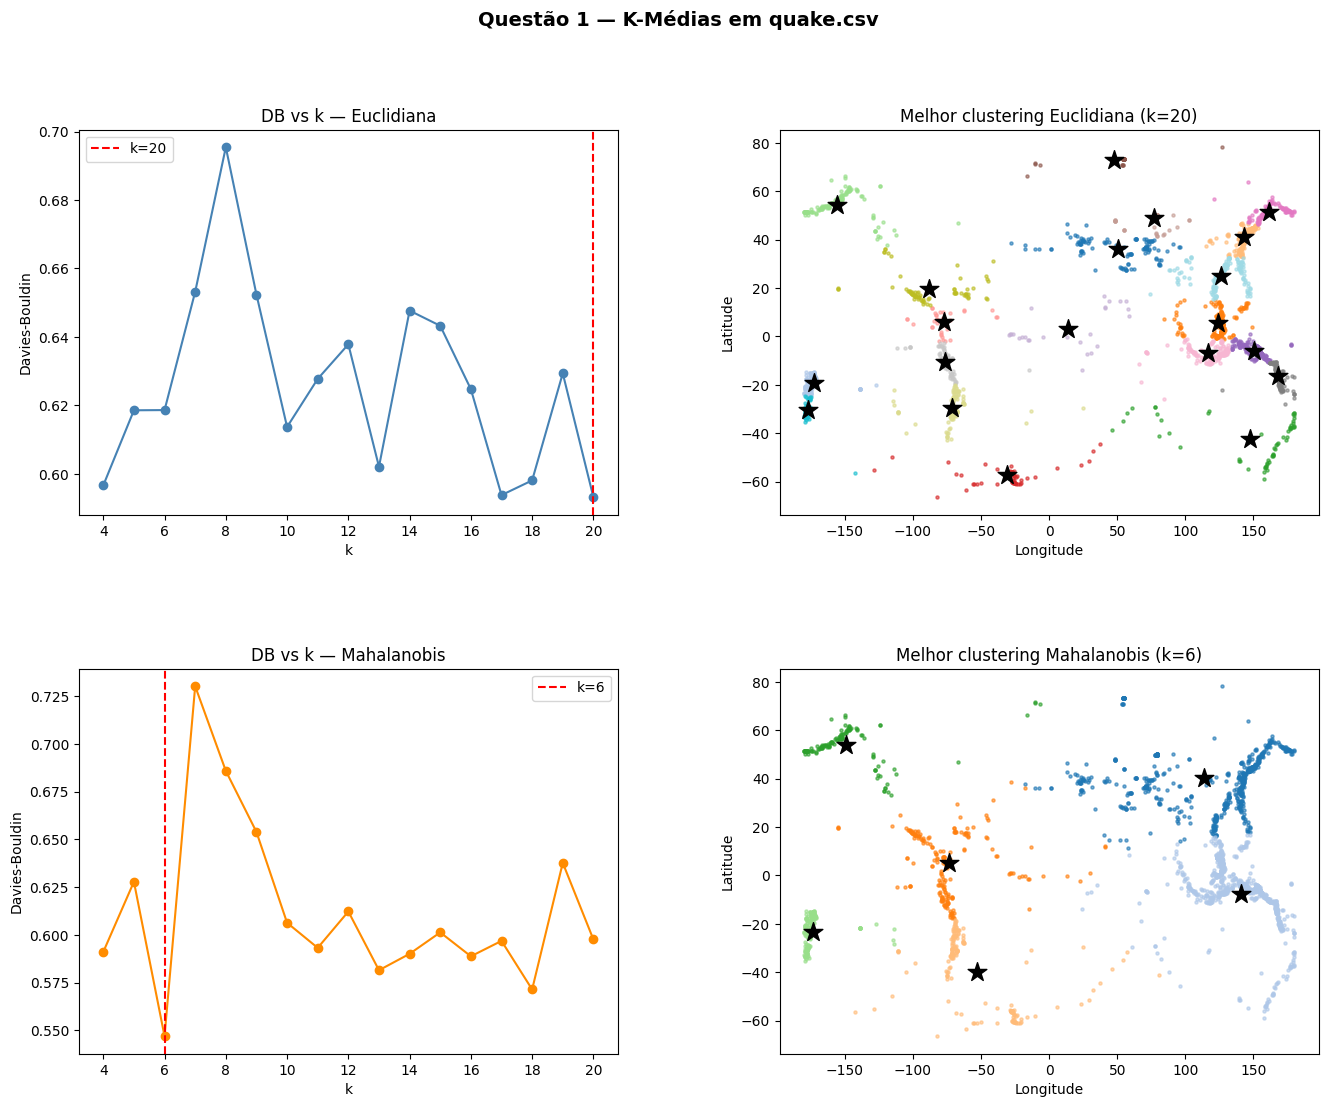


Salvo: q1_resultados.png


In [165]:
questao1()


QUESTÃO 2 — PCA em penguins.csv
Shape: 332 amostras, 4 atributos
  1 componente(s): variância acumulada = 68.59%
  2 componente(s): variância acumulada = 88.08%
  3 componente(s): variância acumulada = 97.31%
  4 componente(s): variância acumulada = 100.00%


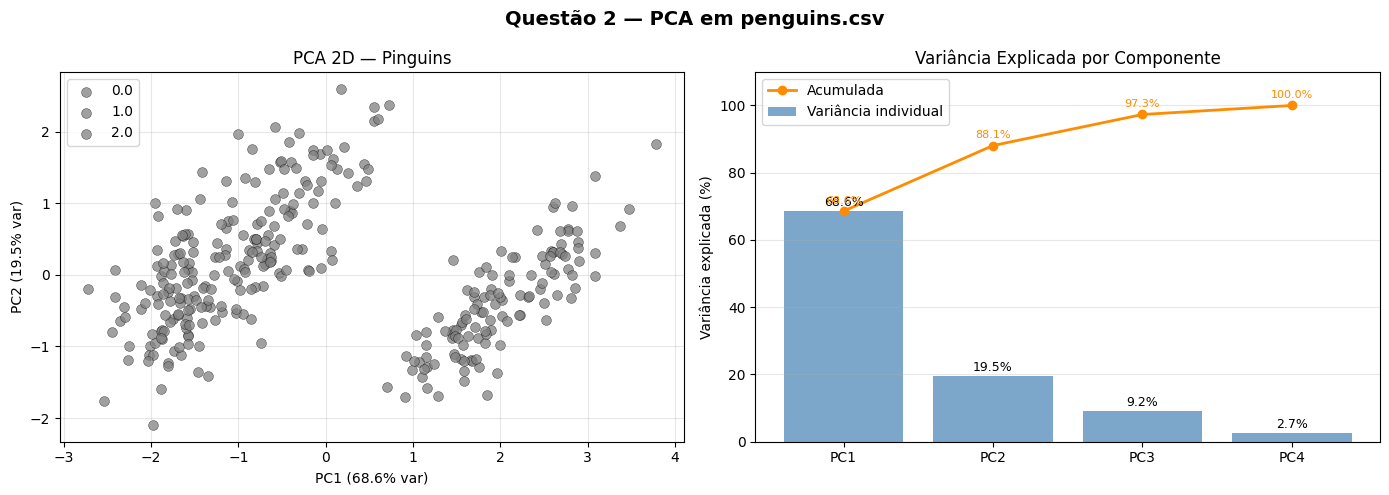


Salvo: q2_resultados.png


In [166]:
questao2()